# Model Evaluation

Notebook ini digunakan untuk mengevaluasi performa model CNN yang telah dilatih.

Evaluasi meliputi:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

In [17]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import numpy as np

import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

import pickle

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report,

    ConfusionMatrixDisplay

)

In [2]:
# ==========================================================
# LABEL NAME
# ==========================================================

label_names = [

    "Anger",

    "Sadness",

    "Neutral",

    "Happiness"

]

In [3]:
# ==========================================================
# LOAD VALIDATION DATASET
# ==========================================================

X = np.load(
    "X_validation.npy"
)

y = np.load(
    "y_validation.npy"
)

print("Validation dataset loaded successfully.")

Validation dataset loaded successfully.


In [4]:
# ==========================================================
# DATASET INFORMATION
# ==========================================================

print("Feature Shape :", X.shape)

print("Label Shape :", y.shape)

Feature Shape : (1377, 128, 215, 1)
Label Shape : (1377,)


In [5]:
# ==========================================================
# LOAD MODEL
# ==========================================================

model = load_model(

    "ser_model_augmented.keras"

)

print("Model loaded successfully.")

Model loaded successfully.


In [6]:
# ==========================================================
# MODEL SUMMARY
# ==========================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 215, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 215, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 107, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64, 107, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 107, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 107, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 53, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 53, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 330,894 (1.26 MB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 220,298 (860.54 KB)

In [7]:
# ==========================================================
# PREDICTION
# ==========================================================

prediction = model.predict(
    X,
    verbose=1
)

prediction.shape

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step


(1377, 4)

In [8]:
# ==========================================================
# PREDICTED LABEL
# ==========================================================

y_pred = np.argmax(

    prediction,

    axis=1

)

print(

    y_pred[:20]

)

[2 2 1 2 3 2 0 1 3 2 3 1 1 3 3 1 2 0 3 1]


In [9]:
# ==========================================================
# TRUE LABEL
# ==========================================================

print(

    y[:20]

)

[1 2 2 1 3 2 3 0 0 2 3 2 1 0 0 1 2 0 3 2]


In [10]:
# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(

    y,

    y_pred

)

print(

    f"Accuracy : {accuracy:.4f}"

)

Accuracy : 0.6304


In [11]:
# ==========================================================
# PRECISION
# ==========================================================

precision = precision_score(

    y,

    y_pred,

    average="weighted"

)

print(

    f"Precision : {precision:.4f}"

)

Precision : 0.6717


In [12]:
# ==========================================================
# RECALL
# ==========================================================

recall = recall_score(

    y,

    y_pred,

    average="weighted"

)

print(

    f"Recall : {recall:.4f}"

)

Recall : 0.6304


In [13]:
# ==========================================================
# F1 SCORE
# ==========================================================

f1 = f1_score(

    y,

    y_pred,

    average="weighted"

)

print(

    f"F1 Score : {f1:.4f}"

)

F1 Score : 0.6246


In [14]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(

    classification_report(

        y,

        y_pred,

        target_names=label_names

    )

)

              precision    recall  f1-score   support

       Anger       0.74      0.64      0.69       320
     Sadness       0.53      0.87      0.66       320
     Neutral       0.60      0.62      0.61       369
   Happiness       0.81      0.42      0.56       368

    accuracy                           0.63      1377
   macro avg       0.67      0.64      0.63      1377
weighted avg       0.67      0.63      0.62      1377



In [15]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y,

    y_pred

)

cm

array([[205,  58,  47,  10],
       [ 10, 277,  29,   4],
       [ 22,  95, 230,  22],
       [ 41,  91,  80, 156]])

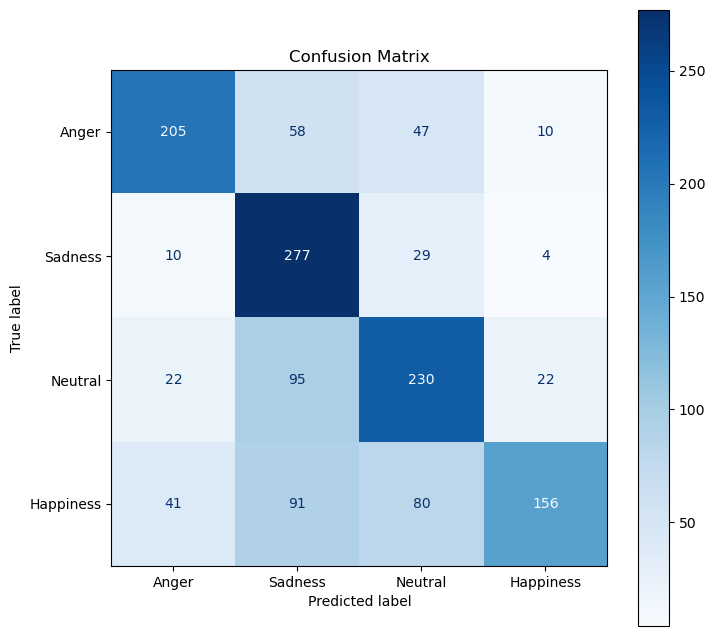

In [16]:
# ==========================================================
# DISPLAY CONFUSION MATRIX
# ==========================================================

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=label_names

)

fig, ax = plt.subplots(

    figsize=(8,8)

)

disp.plot(

    cmap="Blues",

    ax=ax,

    values_format="d"

)

plt.title(

    "Confusion Matrix"

)

plt.show()

In [18]:
# ==========================================================
# LOAD TRAINING HISTORY
# ==========================================================

with open(

    "training_history.pkl",

    "rb"

) as file:

    history = pickle.load(

        file

    )

print("Training history loaded successfully.")

Training history loaded successfully.


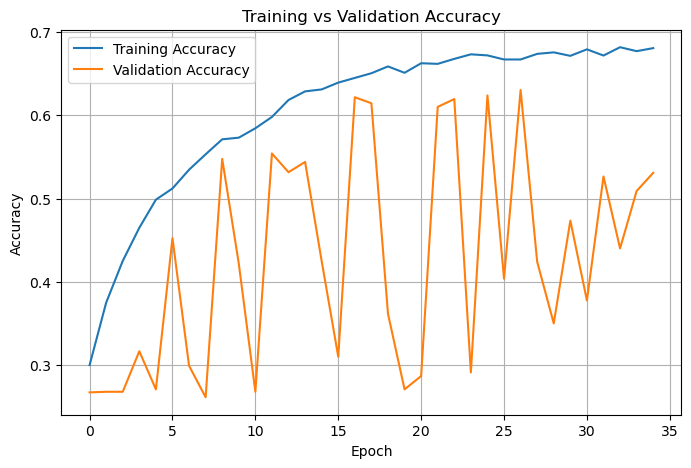

In [19]:
# ==========================================================
# ACCURACY CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title(

    "Training vs Validation Accuracy"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

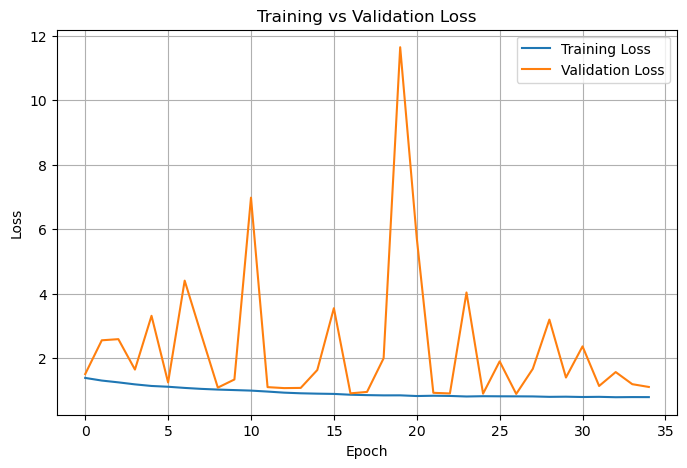

In [20]:
# ==========================================================
# LOSS CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history["loss"],

    label="Training Loss"

)

plt.plot(

    history["val_loss"],

    label="Validation Loss"

)

plt.title(

    "Training vs Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [21]:
# ==========================================================
# EVALUATION SUMMARY
# ==========================================================

print("=" * 45)

print("MODEL EVALUATION SUMMARY")

print("=" * 45)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print("=" * 45)

MODEL EVALUATION SUMMARY
Accuracy  : 0.6304
Precision : 0.6717
Recall    : 0.6304
F1 Score  : 0.6246
